# Competitor Comparison

The purpose of this notebook is to compare the Robust Mixed Effects (RoME) algorithm to various competing algorithms.
This notebook contains three separate simulations that compare these methods.

In the first simulation, the standard Thompson sampling assumptions hold,
and the users are assumed to be homogeneous in the sense that their advantage functions (causal effects) are the same.

The second situation is similar, but users are heterogeneous in the sense that they have different advantage functions.

In the third simulation, the data-generating mechanism is much more complex.
In addition to being nonlinear, it also includes effects for users and time.
Consequently, only the RoME method performs well in this setting.

# Shared Setup

In [1]:
# Generic imports
import pandas as pd
import numpy as np
import scipy
import scipy.sparse
from scipy.stats import ttest_1samp
import matplotlib.pyplot as plt
import seaborn as sns
from river import linear_model
import copy
from multiprocessing import cpu_count
from joblib import Parallel, delayed
import pickle
import tensorflow as tf
import keras
from keras import layers, regularizers
import time

pd.set_option('display.max_rows', 1000)
pd.set_option('display.max_columns', 50)

Matplotlib created a temporary config/cache directory at /tmp/matplotlib-qve1f35l because the default path (/home/jovyan/.cache/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
2025-01-11 22:36:18.964758: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Imports from this project
from models.models import OracleTS, StandardTS, ActionCenteredTS, RoME, IntelligentPooling, UserLaplacian
from models.river_wrapper import RiverBatchEstimator
from models.bagging_mod import BaggingRegressor
from models.utils import find_neighbors
from simulations.data_generator import DataGenerator

In [3]:
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=plt.cm.tab10.colors)
plt.rcParams['font.family'] = 'sans-serif'

In [4]:
# Simulation setup: try some different values
N_STAGES = 200
N_OBSERVATIONS = N_STAGES * (N_STAGES + 1) // 2
N = N_STAGES
T = N_STAGES
THETA = np.array([1., 0.5, -4.])
CONTEXT_DIM = 2
EXTRA_CONTEXT_DIM = 2
LINEAR_BASELINE_COEF = np.array([2., -2., 3.])
THETA_TIME_INIT = np.array([-2., -4., 6.])
P = THETA.size
n_jobs = 25
REPS = 50
N_NEIGHBORS = 10

In [5]:
def get_max_norm(x):
    squared_norms = (x**2).sum(axis=1)
    norms = np.sqrt(squared_norms)
    max_norm = np.max(norms)
    return max_norm

def get_max_norm_for_pairs(x, pairs):
    x_diffs = x[pairs[0]] - x[pairs[1]]
    max_norm = get_max_norm(x_diffs)
    return max_norm

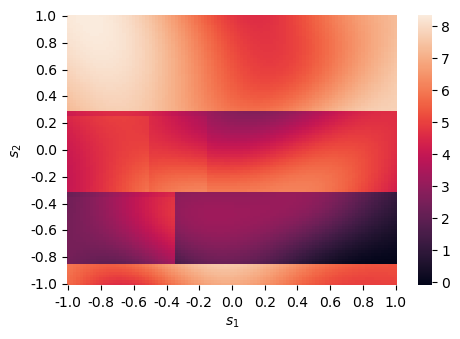

In [6]:
homogeneous_data_generator = DataGenerator(stage_max=N_STAGES, assumptions="homogeneous", linear_baseline_coef=LINEAR_BASELINE_COEF, random_seed=1)
homogeneous_data_generator = homogeneous_data_generator.sample_theta(theta_base=THETA)

heterogeneous_data_generator = DataGenerator(stage_max=N_STAGES, assumptions="heterogeneous", linear_baseline_coef=LINEAR_BASELINE_COEF, random_seed=1)
heterogeneous_data_generator = heterogeneous_data_generator.sample_theta(theta_base=THETA)

nonlinear_data_generator = DataGenerator(stage_max=N_STAGES, assumptions="nonlinear", random_seed=3, nonlinear_scale=1.)  # Seed chosen for its interesting nonlinear relationships
nonlinear_data_generator = nonlinear_data_generator.sample_theta(theta_base=THETA, theta_time_init=THETA_TIME_INIT)

# Baseline Reward
num_vals = 101
s1_vals = np.round(np.linspace(-1., 1., num=num_vals), 2)
s2_vals = np.round(np.linspace(-1., 1., num=num_vals), 2)
s1_vals_repped, s2_vals_repped = np.meshgrid(s1_vals, s2_vals)
context_values = np.vstack([s1_vals_repped.flatten(), s2_vals_repped.flatten()]).T
baseline_vals = nonlinear_data_generator._nonlinear_baseline_function(context_values, scale=nonlinear_data_generator.nonlinear_scale)
heatmap_min = np.min(baseline_vals)
heatmap_max = np.max(baseline_vals)

baseline_vals_df = pd.DataFrame(
    data=baseline_vals.reshape((num_vals, num_vals)),
    index=s1_vals,
    columns=s2_vals).sort_index(ascending=False)

fig, ax = plt.subplots(figsize=(5, 3.5))
ax = sns.heatmap(baseline_vals_df, xticklabels=10, yticklabels=10, ax=ax)
plt.xlabel("$s_{1}$")
plt.ylabel("$s_{2}$")
# plt.title("Baseline Reward as a Function of State")
fig.tight_layout()
fig.savefig("figures/baseline_reward.png")
fig.savefig("figures/baseline_reward.pdf")
plt.show()

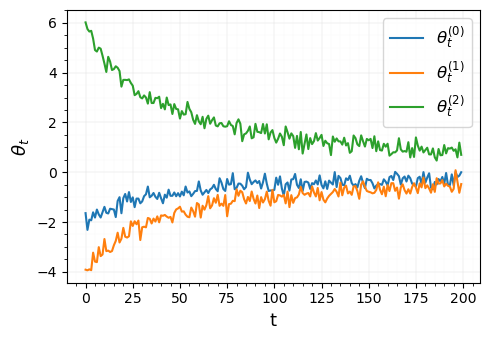

In [7]:
# Time-specifc thetas
fig, ax = plt.subplots(figsize=(5, 3.5))
for i in range(THETA.size):
    label = "$\\theta^{(idx)}_{t}$".replace("idx", str(i))
    ax.plot(nonlinear_data_generator.theta_time[:, i], alpha=1, label=label)
ax.grid(which='major', color='#DDDDDD', linewidth=0.3)
ax.grid(which='minor', color='#EEEEEE', linestyle=':', linewidth=0.3)
ax.minorticks_on()
ax.set_xlabel("t", fontsize=13)
ax.set_ylabel("$\\theta_{t}$", fontsize=13)
# plt.title("Values of $\\theta_{time}$ Plotted Over Time")
ax.legend(fontsize=12)
fig.tight_layout()
fig.savefig("figures/theta_time.png")
fig.savefig("figures/theta_time.pdf")
plt.show()

2025-01-11 22:36:25.175281: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


Epoch 1/20
200/200 [==============================] - 1s 3ms/step - loss: 1.4565 - val_loss: 1.0792
Epoch 2/20
200/200 [==============================] - 0s 2ms/step - loss: 1.0653 - val_loss: 1.0538
Epoch 3/20
200/200 [==============================] - 0s 2ms/step - loss: 1.0498 - val_loss: 1.0479
Epoch 4/20
200/200 [==============================] - 0s 2ms/step - loss: 1.0437 - val_loss: 1.0442
Epoch 5/20
200/200 [==============================] - 0s 2ms/step - loss: 1.0331 - val_loss: 1.0437
Epoch 6/20
200/200 [==============================] - 0s 2ms/step - loss: 1.0361 - val_loss: 1.0556
Epoch 7/20
200/200 [==============================] - 0s 2ms/step - loss: 1.0356 - val_loss: 1.0988
Epoch 8/20
200/200 [==============================] - 0s 2ms/step - loss: 1.0358 - val_loss: 1.0396
Epoch 9/20
200/200 [==============================] - 0s 2ms/step - loss: 1.0277 - val_loss: 1.0324
Epoch 10/20
200/200 [==============================] - 0s 2ms/step - loss: 1.0285 - val_loss: 1.0513

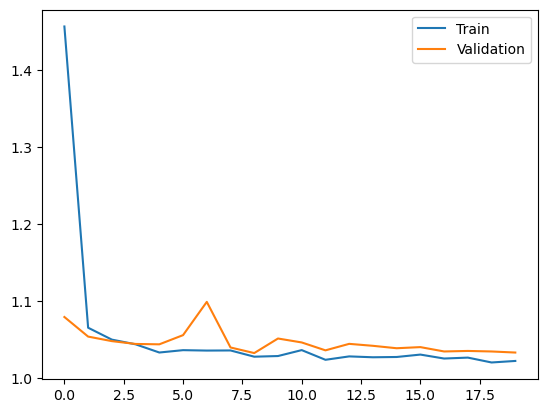

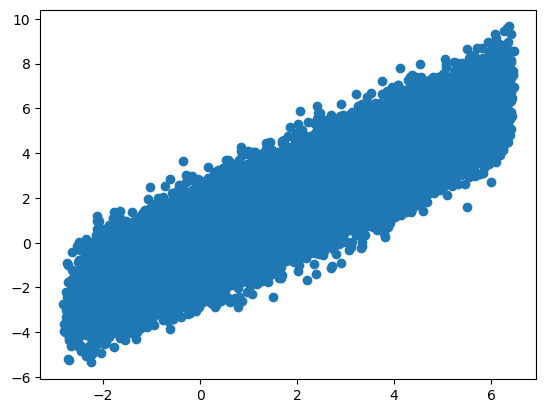

INFO:tensorflow:Assets written to: tri-homogeneous-nn/assets


INFO:tensorflow:Assets written to: tri-homogeneous-nn/assets


Epoch 1/20
200/200 [==============================] - 1s 2ms/step - loss: 1.5129 - val_loss: 1.1187
Epoch 2/20
200/200 [==============================] - 0s 2ms/step - loss: 1.0793 - val_loss: 1.0632
Epoch 3/20
200/200 [==============================] - 0s 2ms/step - loss: 1.0668 - val_loss: 1.0758
Epoch 4/20
200/200 [==============================] - 0s 2ms/step - loss: 1.0560 - val_loss: 1.0493
Epoch 5/20
200/200 [==============================] - 0s 2ms/step - loss: 1.0507 - val_loss: 1.0563
Epoch 6/20
200/200 [==============================] - 0s 2ms/step - loss: 1.0503 - val_loss: 1.0578
Epoch 7/20
200/200 [==============================] - 0s 2ms/step - loss: 1.0441 - val_loss: 1.0543
Epoch 8/20
200/200 [==============================] - 0s 2ms/step - loss: 1.0426 - val_loss: 1.0416
Epoch 9/20
200/200 [==============================] - 0s 2ms/step - loss: 1.0443 - val_loss: 1.0508
Epoch 10/20
200/200 [==============================] - 0s 2ms/step - loss: 1.0433 - val_loss: 1.0642

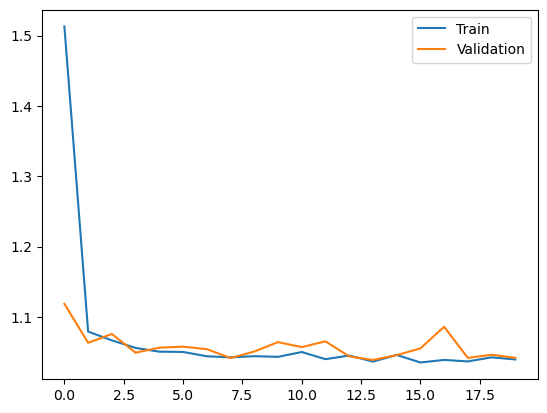

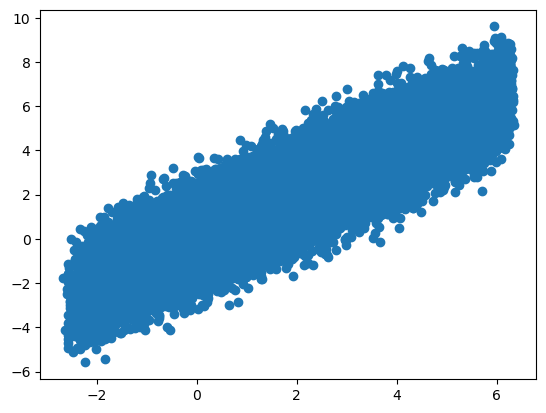

INFO:tensorflow:Assets written to: tri-heterogeneous-nn/assets


INFO:tensorflow:Assets written to: tri-heterogeneous-nn/assets


Epoch 1/50
200/200 [==============================] - 1s 2ms/step - loss: 5.1075 - val_loss: 3.0348
Epoch 2/50
200/200 [==============================] - 0s 2ms/step - loss: 2.3854 - val_loss: 1.8809
Epoch 3/50
200/200 [==============================] - 0s 2ms/step - loss: 1.7806 - val_loss: 1.7570
Epoch 4/50
200/200 [==============================] - 0s 2ms/step - loss: 1.6002 - val_loss: 1.5581
Epoch 5/50
200/200 [==============================] - 0s 2ms/step - loss: 1.5282 - val_loss: 1.5809
Epoch 6/50
200/200 [==============================] - 0s 2ms/step - loss: 1.4613 - val_loss: 1.4511
Epoch 7/50
200/200 [==============================] - 0s 2ms/step - loss: 1.4237 - val_loss: 1.4786
Epoch 8/50
200/200 [==============================] - 0s 2ms/step - loss: 1.4076 - val_loss: 1.4609
Epoch 9/50
200/200 [==============================] - 0s 2ms/step - loss: 1.4155 - val_loss: 1.5305
Epoch 10/50
200/200 [==============================] - 0s 2ms/step - loss: 1.4032 - val_loss: 1.3917

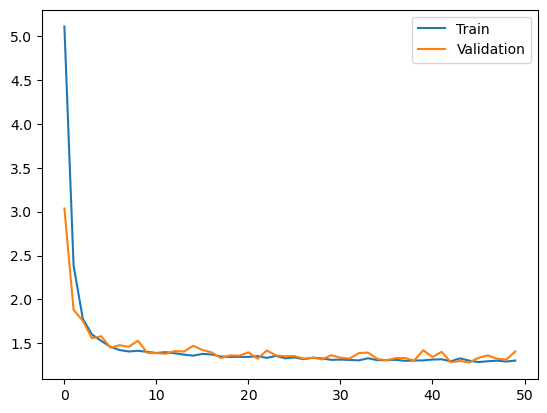

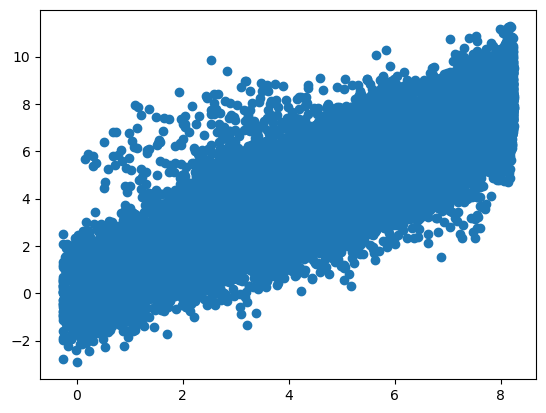

INFO:tensorflow:Assets written to: tri-nonlinear-nn/assets


INFO:tensorflow:Assets written to: tri-nonlinear-nn/assets


In [8]:
# Neural network stuff
nn_input_dim = CONTEXT_DIM + EXTRA_CONTEXT_DIM

data_generators = [homogeneous_data_generator, heterogeneous_data_generator, nonlinear_data_generator]
model_files = ["tri-homogeneous-nn", "tri-heterogeneous-nn", "tri-nonlinear-nn"]
for i, (data_generator, model_file) in enumerate(zip(data_generators, model_files)):
    # Create data
    data_generator = data_generator.generate_all_contexts(context_dim=CONTEXT_DIM, extra_context_dim=EXTRA_CONTEXT_DIM)
    X_train, y_train = data_generator.generate_baselines_for_nn()
    
    data_generator = data_generator.reset()
    data_generator = data_generator.generate_all_contexts(context_dim=CONTEXT_DIM, extra_context_dim=EXTRA_CONTEXT_DIM)
    X_validation, y_validation = data_generator.generate_baselines_for_nn()
    
    # Train model
    penalty = 0.001
    nn_output_dim = 10
    model = keras.Sequential(
        [
            keras.Input(shape=(nn_input_dim,), name="input"),
            layers.Dense(10, activation="relu", name="layer1", kernel_regularizer=regularizers.l2(penalty)),
            layers.Dense(20, activation="relu", name="layer2", kernel_regularizer=regularizers.l2(penalty)),
            layers.Dense(20, activation="tanh", name="layer3", kernel_regularizer=regularizers.l2(penalty)),
            layers.Dense(nn_output_dim, activation="tanh", name="layer4", kernel_regularizer=regularizers.l2(penalty)),
            layers.Dense(1, name="output", kernel_regularizer=regularizers.l2(penalty)),
        ]
    )
    opt = keras.optimizers.Adam(learning_rate=0.01)
    model.compile(loss="mse", optimizer=opt)
    history = model.fit(
        X_train,
        y_train,
        batch_size=200,
        validation_data=(X_validation, y_validation),
        epochs=50 if i == 2 else 20,
        # epochs=1,
        verbose=1
    )
    
    plt.plot(history.history['loss'], label="Train")
    plt.plot(history.history['val_loss'], label="Validation")
    plt.legend()
    plt.show()

    preds_validation = model(X_validation)
    plt.scatter(preds_validation, y_validation)
    plt.show()
    
    # Featurizer model
    featurizer_nn_model = keras.Model(
        inputs=model.input,
        outputs=model.get_layer("layer4").output)
    featurizer_nn_model.compile()
    featurizer_nn_model.save(model_file)

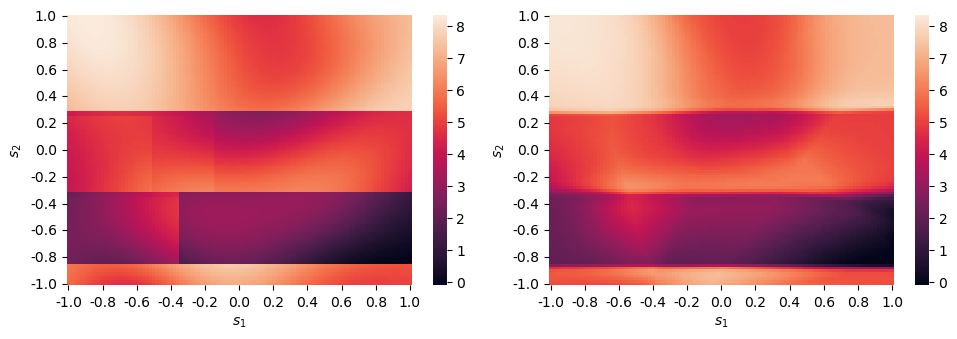

In [9]:
# Baseline Reward
num_vals = 101
s1_vals = np.round(np.linspace(-1., 1., num=num_vals), 2)
s2_vals = np.round(np.linspace(-1., 1., num=num_vals), 2)
s1_vals_repped, s2_vals_repped = np.meshgrid(s1_vals, s2_vals)
context_values = np.vstack([s1_vals_repped.flatten(), s2_vals_repped.flatten()]).T
baseline_vals = nonlinear_data_generator._nonlinear_baseline_function(context_values, scale=nonlinear_data_generator.nonlinear_scale)

baseline_vals_df = pd.DataFrame(
    data=baseline_vals.reshape((num_vals, num_vals)),
    index=s1_vals,
    columns=s2_vals).sort_index(ascending=False)

fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
sns.heatmap(baseline_vals_df, vmin=heatmap_min, vmax=heatmap_max, xticklabels=10, yticklabels=10, ax=ax[0])
ax[0].set_xlabel("$s_{1}$")
ax[0].set_ylabel("$s_{2}$")

nn_context_values = np.hstack([context_values, np.zeros_like(context_values)])
nn_baseline_vals = model(nn_context_values).numpy()
nn_baseline_vals_df = pd.DataFrame(
    data=nn_baseline_vals.reshape((num_vals, num_vals)),
    index=s1_vals,
    columns=s2_vals).sort_index(ascending=False)

sns.heatmap(nn_baseline_vals_df, vmin=heatmap_min, vmax=heatmap_max, xticklabels=10, yticklabels=10, ax=ax[1])
ax[1].set_xlabel("$s_{1}$")
ax[1].set_ylabel("$s_{2}$")

fig.tight_layout()
fig.savefig("figures/nn_baseline_reward_comparison.png")
fig.savefig("figures/nn_baseline_reward_comparison.pdf")
plt.show()

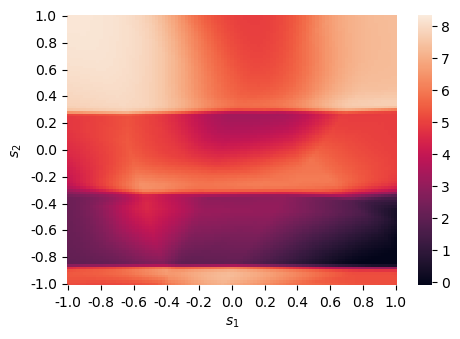

In [10]:
fig, ax = plt.subplots(figsize=(5, 3.5))
ax = sns.heatmap(nn_baseline_vals_df, vmin=heatmap_min, vmax=heatmap_max, xticklabels=10, yticklabels=10, ax=ax)
plt.xlabel("$s_{1}$")
plt.ylabel("$s_{2}$")
# plt.title("Baseline Reward as a Function of State")
fig.tight_layout()
fig.savefig("figures/nn_baseline_reward.png")
fig.savefig("figures/nn_baseline_reward.pdf")
plt.show()

In [11]:
# This determines the plotting order
non_oracle_method_names = [
    "IntelPooling",
    "RoME-BLM",
    "RoME",
    "RoME-SU",
    "AC",
    "Standard",
    "Neural-Linear",
    "NNR-Linear"
]

def create_reward_dict(data_generator, nn_model_name, seed):
    np.random.seed(seed)
    user_pairs, L_user = find_neighbors(data_generator.theta_user, N_NEIGHBORS)
    time_pairs, L_time = find_neighbors(data_generator.theta_time, N_NEIGHBORS)
    
    bagged_lm = RiverBatchEstimator(
        BaggingRegressor(
            linear_model.LinearRegression(l2=1e-8, intercept_lr=0.1),
            n_models=10,
            subsample=0.8
        )
    )

    # Set covariances
    cov_epsilon = 1e-18
    user_cov = np.cov(data_generator.theta_user.T)
    if user_cov.sum() < cov_epsilon:
        user_cov += cov_epsilon * np.eye(user_cov.shape[0])
    time_cov = np.cov(data_generator.theta_time.T)
    if time_cov.sum() < cov_epsilon:
        time_cov += cov_epsilon * np.eye(time_cov.shape[0])

    nn = tf.keras.models.load_model(nn_model_name)
    nn_numpy = lambda x: nn(x).numpy()
    
    non_oracle_methods_dict = {
        "IntelPooling": IntelligentPooling(N, T, P, DataGenerator._featurize, user_cov=user_cov, time_cov=time_cov),
        "RoME": RoME(N, T, P, DataGenerator._featurize, L_user, L_time, user_cov=user_cov, time_cov=time_cov, n_neighbors=N_NEIGHBORS),
        "RoME-BLM": RoME(N, T, P, DataGenerator._featurize, L_user, L_time, user_cov=user_cov, time_cov=time_cov, ml_interactions=True, ml_model=bagged_lm, n_neighbors=N_NEIGHBORS),
        "RoME-SU": RoME(1, T, P, DataGenerator._featurize, L_user, L_time, user_cov=user_cov, time_cov=time_cov, n_neighbors=N_NEIGHBORS, pool_users=False),
        "AC": ActionCenteredTS(N, T, P, DataGenerator._featurize),
        "Standard": StandardTS(N, T, P, DataGenerator._featurize),
        "Neural-Linear": StandardTS(N, T, P, DataGenerator._featurize, nn=nn_numpy, nn_dim=nn_output_dim),
        "NNR-Linear": UserLaplacian(N, T, P, DataGenerator._featurize, L_user, user_cov=user_cov),
    }
    methods_dict = copy.copy(non_oracle_methods_dict)
    methods_dict["Oracle"] = OracleTS(N, T, THETA, data_generator.theta_user, data_generator.theta_time, DataGenerator._featurize)
    
    # Dictionary for storing rewards
    rewards_dict = {k:np.zeros((N, T)) for k in methods_dict}
    timings_dict = {}

    # Generate context vectors that we'll use for all models
    data_generator = data_generator.generate_all_contexts(context_dim=CONTEXT_DIM, extra_context_dim=EXTRA_CONTEXT_DIM)

    # Iterate through methods
    for method_name, method in methods_dict.items():
        rewards = []
        data_generator = data_generator.reset()
        method.reset()
        method_start_time = time.time()

        while not data_generator.finished:
            # Randomly samples action from current policy
            context, context_extra, user_idx, time_idx = data_generator.get_current_context()
            action = method.sample_action(context, user_idx, time_idx)

            # Plays action and returns reward
            reward = data_generator.play_action(action)
            rewards_dict[method_name][user_idx, time_idx] = reward

            # Update method inferences
            method.update(context, context_extra, user_idx, time_idx, action, reward)
        method_end_time = time.time()
        method_elapsed_time = method_end_time - method_start_time
        timings_dict[method_name] = method_elapsed_time

    return rewards_dict, timings_dict

In [12]:
def run_simulation(data_generator, nn_model_name, REPS=REPS, n_jobs=cpu_count()):    
    # Perform whole simulation REPS times
    pool_args = zip(
        [copy.deepcopy(data_generator) for _ in range(REPS)],
        [nn_model_name]*REPS,
        range(REPS))
    print("Starting parallel")
    list_of_tuples_of_dicts = Parallel(n_jobs=n_jobs)(delayed(create_reward_dict)(*arg) for arg in pool_args)    
    print("Parallel closed")
    rewards_list_of_dicts = [t[0] for t in list_of_tuples_of_dicts]
    timings_list_of_dicts = [t[1] for t in list_of_tuples_of_dicts]
    rewards_dict = {}
    timings_dict = {}
    method_names = list(rewards_list_of_dicts[0].keys())
    non_oracle_method_names = list(set(method_names) - set(["Oracle"]))
    for method_name in method_names:
        rewards_dict[method_name] = np.asarray([
            rewards_list_of_dicts[i][method_name]
            for i in range(REPS)])
        timings_dict[method_name] = np.asarray([
            timings_list_of_dicts[i][method_name]
            for i in range(REPS)])
                
    return rewards_dict, timings_dict

In [13]:
def get_avg_stage_reward(a):
    means = [a[:, ::-1].diagonal(i, axis1=1, axis2=2).mean(axis=1) for i in range(-a.shape[1]+1,a.shape[2])]
    return np.asarray(means)[:a.shape[1]]


def plot_rewards_dict(rewards_dict, assumptions):
    fig, ax = plt.subplots(1, 2, figsize=(8, 4))
    ax0 = ax[0]
    ax1 = ax[1]
    
    # Calculate incremental regret
    oracle_incremental_regret = get_avg_stage_reward(rewards_dict["Oracle"])
    incremental_regret_dict = {
        method_name: (oracle_incremental_regret - get_avg_stage_reward(rewards_dict[method_name])).mean(axis=1)  # Mean over reps
        for method_name in non_oracle_method_names}

    # Calculate cumulative regret
    cumulative_regret_dict = {method_name: np.cumsum(incremental_regret_dict[method_name]) for method_name in non_oracle_method_names}

    # Plot incremental regret
    for method_name in non_oracle_method_names:
        ax0.plot(incremental_regret_dict[method_name], label=method_name, )
    ax0.set_title("(a) Incremental Regret Over Time", pad=10)
    ax0.set_ylabel("Incremental Regret")
    ax0.set_xlabel("Stage")
    ax0.legend()

    # Plot cumulative regret
    for method_name in non_oracle_method_names:
        ax1.plot(cumulative_regret_dict[method_name], label=method_name)
    ax1.set_title("(b) Cumulative Regret Over Time", pad=10)
    ax1.set_ylabel("Cumulative Regret")
    ax1.set_xlabel("Stage")
    plt.legend()

    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    fig.savefig(f"figures/{assumptions}-regret.png")
    fig.savefig(f"figures/{assumptions}-regret.pdf")
    fig.suptitle(f"Regret for {assumptions.capitalize()} Data-Generating Process")
    plt.show()

# Simulation 1: Homogeneous Users, Linear Baseline, No Time Effects

In [14]:
homogeneous_rewards_dict, homogeneous_timings_dict = run_simulation(homogeneous_data_generator, model_files[0], n_jobs=n_jobs)

Starting parallel


2025-01-11 22:37:07.180031: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-01-11 22:37:07.183236: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-01-11 22:37:07.192623: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 

Parallel closed


In [15]:
def print_timings(timings_dict_):
    print("Average elapsed time by method")
    for k in timings_dict_:
        mean_timing = timings_dict_[k].mean()
        print(f"{k}: {mean_timing}")
    timings_df = pd.DataFrame(timings_dict_)
    print(timings_df)
    return timings_df
print_timings(homogeneous_timings_dict)

Average elapsed time by method
IntelPooling: 46.22709966182709
RoME: 412.0680216836929
RoME-BLM: 101.87106295585632
RoME-SU: 401.67376673698425
AC: 0.11638527393341064
Standard: 0.16131938457489015
Neural-Linear: 0.7399191093444825
NNR-Linear: 30.07553886413574
Oracle: 0.019679627418518066
    IntelPooling        RoME    RoME-BLM     RoME-SU        AC  Standard  \
0      47.049546  368.421929  101.237967  360.750128  0.117272  0.160398   
1      47.074410  375.796106  100.234847  372.895667  0.113503  0.158091   
2      47.666556  377.760899  101.976130  372.050057  0.115236  0.159224   
3      47.078459  372.239923  101.031808  369.967183  0.116752  0.161015   
4      47.399859  379.064917  101.756164  373.139242  0.115545  0.160449   
5      41.543807  394.557740  102.610314  420.318920  0.126601  0.175842   
6      47.119684  380.416929  101.001972  376.070784  0.114770  0.160694   
7      46.798176  378.398396  101.130416  379.582573  0.113873  0.158578   
8      46.809601  379.364

,IntelPooling,RoME,RoME-BLM,RoME-SU,AC,Standard,Neural-Linear,NNR-Linear,Oracle
0,47.049546,368.421929,101.237967,360.750128,0.117272,0.160398,0.764369,29.809144,0.018640
1,47.074410,375.796106,100.234847,372.895667,0.113503,0.158091,0.732875,29.688813,0.019576
2,47.666556,377.760899,101.976130,372.050057,0.115236,0.159224,0.727510,30.364579,0.020295
3,47.078459,372.239923,101.031808,369.967183,0.116752,0.161015,0.740422,30.284878,0.022362
4,47.399859,379.064917,101.756164,373.139242,0.115545,0.160449,0.749666,30.600986,0.019171
5,41.543807,394.557740,102.610314,420.318920,0.126601,0.175842,0.920476,33.519900,0.022527
6,47.119684,380.416929,101.001972,376.070784,0.114770,0.160694,0.746396,30.055615,0.020043
7,46.798176,378.398396,101.130416,379.582573,0.113873,0.158578,0.734315,29.856542,0.019495
8,46.809601,379.364335,101.194233,369.762122,0.113614,0.158516,0.784028,30.125826,0.019722
9,47.598429,376.793182,101.730076,368.560378,0.114199,0.158950,0.746317,29.686576,0.019889


In [16]:
homogeneous_rewards_filename = "checkpoints/homogeneous_rewards.pkl"
with open(homogeneous_rewards_filename, 'wb') as file:
    pickle.dump(homogeneous_rewards_dict, file, protocol=pickle.HIGHEST_PROTOCOL)

In [17]:
with open(homogeneous_rewards_filename, "rb") as file:
    homogeneous_rewards_dict = pickle.load(file)

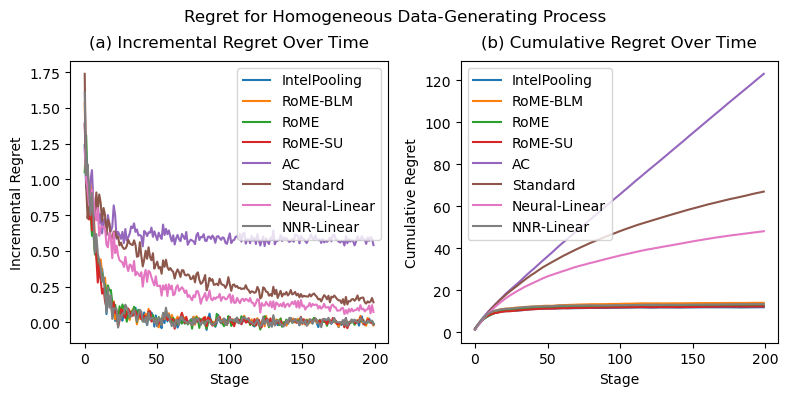

In [18]:
plot_rewards_dict(homogeneous_rewards_dict, "homogeneous")

# Simulation 2: Heterogeneous Users, Linear Baseline, No Time Effects

In [19]:
heterogeneous_rewards_dict, heterogeneous_timings_dict = run_simulation(heterogeneous_data_generator, model_files[1], n_jobs=n_jobs)

Starting parallel


2025-01-11 23:17:43.511374: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-01-11 23:17:43.745689: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-01-11 23:17:43.758171: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 

Parallel closed


In [20]:
print_timings(heterogeneous_timings_dict)

Average elapsed time by method
IntelPooling: 43.53019436836243
RoME: 433.10598024368284
RoME-BLM: 112.13450902938843
RoME-SU: 391.8971995830536
AC: 0.1158211898803711
Standard: 0.16196271896362305
Neural-Linear: 0.7228058624267578
NNR-Linear: 31.856398873329162
Oracle: 0.01981351375579834
    IntelPooling        RoME    RoME-BLM     RoME-SU        AC  Standard  \
0      45.350140  433.017660  120.746154  361.997536  0.115206  0.159003   
1      45.551295  406.370600  117.130247  385.458521  0.115944  0.160362   
2      45.717175  436.427932  115.799809  370.214251  0.116727  0.160338   
3      46.726088  410.561759  120.650598  379.075523  0.116744  0.160464   
4      46.368195  434.657740  120.811077  363.117527  0.117628  0.161617   
5      44.922253  432.764901  122.465195  371.068829  0.117540  0.158146   
6      46.631620  406.333313  122.044311  394.746118  0.117246  0.159748   
7      46.173645  427.333339  125.799963  387.508561  0.115036  0.161017   
8      46.171494  396.7400

,IntelPooling,RoME,RoME-BLM,RoME-SU,AC,Standard,Neural-Linear,NNR-Linear,Oracle
0,45.350140,433.017660,120.746154,361.997536,0.115206,0.159003,0.724363,31.122327,0.019567
1,45.551295,406.370600,117.130247,385.458521,0.115944,0.160362,0.748547,31.631306,0.019868
2,45.717175,436.427932,115.799809,370.214251,0.116727,0.160338,0.746445,31.761196,0.020225
3,46.726088,410.561759,120.650598,379.075523,0.116744,0.160464,0.750065,35.817322,0.020051
4,46.368195,434.657740,120.811077,363.117527,0.117628,0.161617,0.744204,33.829823,0.022344
5,44.922253,432.764901,122.465195,371.068829,0.117540,0.158146,0.739605,31.799511,0.019360
6,46.631620,406.333313,122.044311,394.746118,0.117246,0.159748,0.750701,31.247751,0.019614
7,46.173645,427.333339,125.799963,387.508561,0.115036,0.161017,0.763450,31.998857,0.020135
8,46.171494,396.740052,118.575300,382.004871,0.115007,0.159780,0.745645,31.764680,0.018118
9,45.549032,395.235220,118.314491,382.294242,0.114287,0.158497,0.727112,31.091575,0.019851


In [21]:
heterogeneous_rewards_filename = "checkpoints/heterogeneous_rewards.pkl"
with open(heterogeneous_rewards_filename, 'wb') as file:
    pickle.dump(heterogeneous_rewards_dict, file, protocol=pickle.HIGHEST_PROTOCOL)

In [22]:
with open(heterogeneous_rewards_filename, "rb") as file:
    heterogeneous_rewards_dict = pickle.load(file)

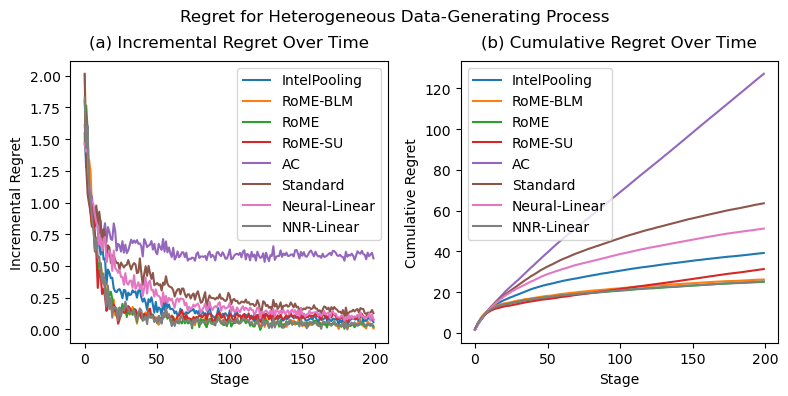

In [23]:
plot_rewards_dict(heterogeneous_rewards_dict, "heterogeneous")

# Simulation 3: Nonlinear Baseline and User-/Time-specific Effects

In [24]:
nonlinear_rewards_dict, nonlinear_timings_dict = run_simulation(nonlinear_data_generator, model_files[2], n_jobs=n_jobs)

Starting parallel


2025-01-12 00:00:36.885700: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-01-12 00:00:36.911741: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-01-12 00:00:36.911741: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 

Parallel closed


In [25]:
print_timings(nonlinear_timings_dict)

Average elapsed time by method
IntelPooling: 44.706874566078184
RoME: 444.3353434753418
RoME-BLM: 126.2539343881607
RoME-SU: 423.4336586046219
AC: 0.26067590713500977
Standard: 0.30970348834991457
Neural-Linear: 0.9182724285125733
NNR-Linear: 32.48645683765412
Oracle: 0.1569724988937378
    IntelPooling        RoME    RoME-BLM     RoME-SU        AC  Standard  \
0      41.966556  408.045116  129.558203  455.128249  0.274381  0.329183   
1      45.131142  405.189543  125.433875  386.668535  0.254687  0.438303   
2      46.168428  414.099922  127.709639  397.075943  0.253814  0.297805   
3      46.218719  409.401948  127.447149  383.253286  0.264194  0.309480   
4      46.228920  424.586767  125.283208  402.802417  0.260887  0.337490   
5      45.945040  411.468255  126.053949  396.225903  0.256084  0.301910   
6      40.914442  393.772011  126.580170  440.750165  0.274375  0.332364   
7      45.630901  411.267360  126.267543  392.368821  0.258893  0.301474   
8      45.897905  420.264318

,IntelPooling,RoME,RoME-BLM,RoME-SU,AC,Standard,Neural-Linear,NNR-Linear,Oracle
0,41.966556,408.045116,129.558203,455.128249,0.274381,0.329183,1.205529,34.306543,0.163110
1,45.131142,405.189543,125.433875,386.668535,0.254687,0.438303,0.900827,31.885067,0.154562
2,46.168428,414.099922,127.709639,397.075943,0.253814,0.297805,0.913533,32.793700,0.154563
3,46.218719,409.401948,127.447149,383.253286,0.264194,0.309480,0.917622,32.772189,0.163296
4,46.228920,424.586767,125.283208,402.802417,0.260887,0.337490,0.940027,33.976013,0.161922
5,45.945040,411.468255,126.053949,396.225903,0.256084,0.301910,0.925263,32.677625,0.153406
6,40.914442,393.772011,126.580170,440.750165,0.274375,0.332364,1.124881,33.923516,0.160669
7,45.630901,411.267360,126.267543,392.368821,0.258893,0.301474,0.926841,31.994928,0.154900
8,45.897905,420.264318,126.363840,392.585001,0.256389,0.301163,0.915688,32.002686,0.154749
9,45.903192,402.873539,126.403712,386.086161,0.259912,0.305108,0.897166,31.887772,0.154814


In [26]:
nonlinear_rewards_filename = "checkpoints/nonlinear_rewards.pkl"
with open(nonlinear_rewards_filename, 'wb') as file:
    pickle.dump(nonlinear_rewards_dict, file, protocol=pickle.HIGHEST_PROTOCOL)

In [27]:
with open(nonlinear_rewards_filename, "rb") as file:
    nonlinear_rewards_dict = pickle.load(file)

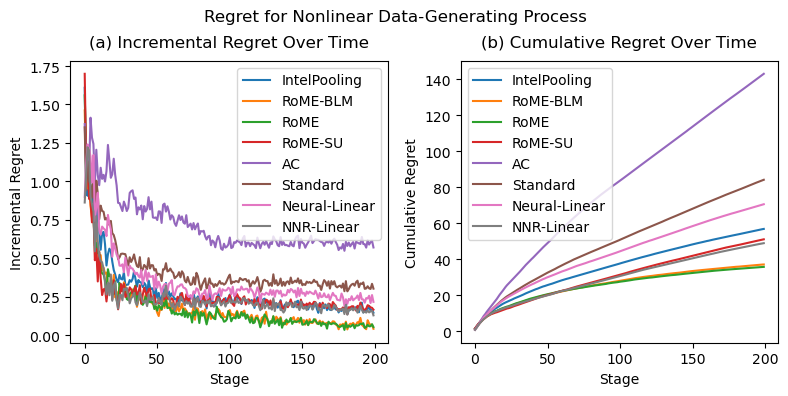

In [28]:
plot_rewards_dict(nonlinear_rewards_dict, "nonlinear")

# Cumulative Regret for All Three Settings

## Calculations

In [29]:
# Calculate incremental regret
incremental_homogeneous_regret_dict = {
    method_name: get_avg_stage_reward(homogeneous_rewards_dict["Oracle"]) - get_avg_stage_reward(homogeneous_rewards_dict[method_name])
    for method_name in non_oracle_method_names}
incremental_heterogeneous_regret_dict = {
    method_name: get_avg_stage_reward(heterogeneous_rewards_dict["Oracle"]) - get_avg_stage_reward(heterogeneous_rewards_dict[method_name])
    for method_name in non_oracle_method_names}
incremental_nonlinear_regret_dict = {
    method_name: get_avg_stage_reward(nonlinear_rewards_dict["Oracle"]) - get_avg_stage_reward(nonlinear_rewards_dict[method_name])
    for method_name in non_oracle_method_names}

# Calculate cumulative regret
cumulative_homogeneous_regret_dict = {method_name: np.cumsum(incremental_homogeneous_regret_dict[method_name], axis=0) for method_name in non_oracle_method_names}
cumulative_heterogeneous_regret_dict = {method_name: np.cumsum(incremental_heterogeneous_regret_dict[method_name], axis=0) for method_name in non_oracle_method_names}
cumulative_nonlinear_regret_dict = {method_name: np.cumsum(incremental_nonlinear_regret_dict[method_name], axis=0) for method_name in non_oracle_method_names}

# Final regret
final_homogeneous_regret_df = pd.DataFrame({
    method_name: cumulative_homogeneous_regret_dict[method_name][-1]
    for method_name in non_oracle_method_names})
final_homogeneous_regret_df.to_csv("./checkpoints/final_homogeneous_regret.csv", index=False)

final_heterogeneous_regret_df = pd.DataFrame({
    method_name: cumulative_heterogeneous_regret_dict[method_name][-1]
    for method_name in non_oracle_method_names})
final_heterogeneous_regret_df.to_csv("./checkpoints/final_heterogeneous_regret.csv", index=False)

final_nonlinear_regret_df = pd.DataFrame({
    method_name: cumulative_nonlinear_regret_dict[method_name][-1]
    for method_name in non_oracle_method_names})
final_nonlinear_regret_df.to_csv("./checkpoints/final_nonlinear_regret.csv", index=False)

## Plots

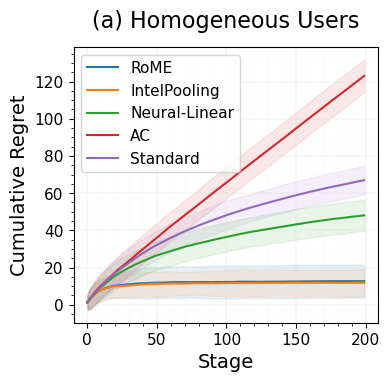

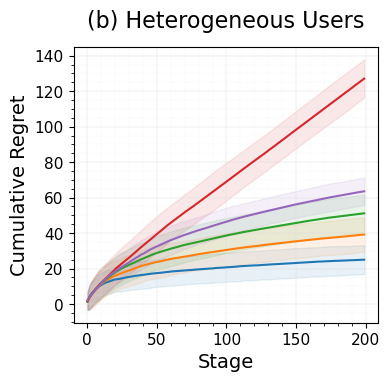

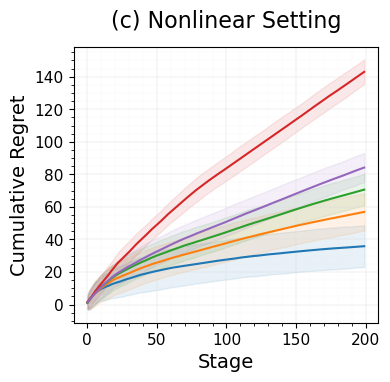

In [30]:
def plot_cumulative_regret(cumulative_regret_dict, setting_name, include_legend=False, loc="main", include_bands=True):
    fig, ax = plt.subplots(1, 1, figsize=(4,4))
    for i, method_name in enumerate(cumulative_regret_dict.keys()):
        color_i = f"C{i}"
        method_means = cumulative_regret_dict[method_name].mean(axis=1)
        method_range = np.arange(method_means.size)
        method_sds = cumulative_regret_dict[method_name].std(axis=1)
        method_lower = method_means - 1.96 * method_sds
        method_upper = method_means + 1.96 * method_sds
        if include_bands:
            ax.fill_between(method_range, method_lower, method_upper, color=color_i, alpha=0.1)
        ax.plot(method_range, method_means, label=method_name, color=color_i)
        
    ax.grid(which='major', color='#DDDDDD', linewidth=0.3)
    ax.grid(which='minor', color='#EEEEEE', linestyle=':', linewidth=0.3)
    ax.minorticks_on()
    ax.set_title(setting_name, pad=14, fontsize=16)
    ax.set_ylabel("Cumulative Regret", fontsize=14)
    ax.set_xlabel("Stage", fontsize=14)
    ax.tick_params(axis='both', labelsize=11)
    if include_legend:
        ax.legend(fontsize=11)

    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    setting_name_for_file = setting_name.replace("(", "").replace(")", "").replace(" ", "-")
    fig.savefig(f"figures/cumulative-regret-{setting_name_for_file}-{loc}.png")
    fig.savefig(f"figures/cumulative-regret-{setting_name_for_file}-{loc}.pdf")
    # fig.suptitle("Comparison of Cumulative Regret by Method")
    plt.show()

main_paper_methods = ["RoME", "IntelPooling", "Neural-Linear", "AC", "Standard"]

plot_cumulative_regret(
    {m:cumulative_homogeneous_regret_dict[m] for m in main_paper_methods},
    setting_name="(a) Homogeneous Users", include_legend=True)

plot_cumulative_regret(
    {m:cumulative_heterogeneous_regret_dict[m] for m in main_paper_methods},
    setting_name="(b) Heterogeneous Users", include_legend=False)

plot_cumulative_regret(
    {m:cumulative_nonlinear_regret_dict[m] for m in main_paper_methods},
    setting_name="(c) Nonlinear Setting", include_legend=False)

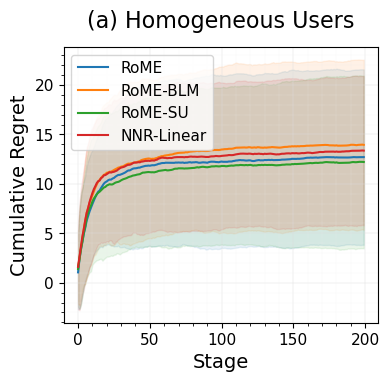

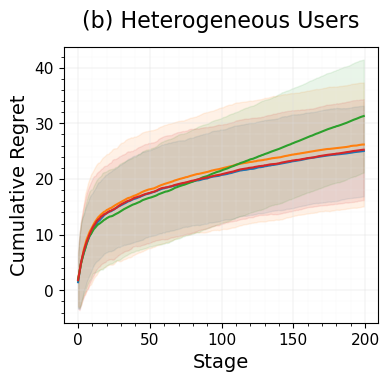

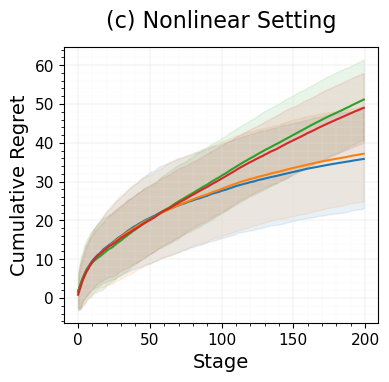

In [31]:
appendix_methods = ["RoME", "RoME-BLM", "RoME-SU", "NNR-Linear"]

plot_cumulative_regret(
    {m:cumulative_homogeneous_regret_dict[m] for m in appendix_methods},
    setting_name="(a) Homogeneous Users", include_legend=True, loc="app")

plot_cumulative_regret(
    {m:cumulative_heterogeneous_regret_dict[m] for m in appendix_methods},
    setting_name="(b) Heterogeneous Users", include_legend=False, loc="app")

plot_cumulative_regret(
    {m:cumulative_nonlinear_regret_dict[m] for m in appendix_methods},
    setting_name="(c) Nonlinear Setting", include_legend=False, loc="app")

## Comparison Tables

### Extra

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
final_homogeneous_regret_df = pd.read_csv("./checkpoints/final_homogeneous_regret.csv")
final_heterogeneous_regret_df = pd.read_csv("./checkpoints/final_heterogeneous_regret.csv")
final_nonlinear_regret_df = pd.read_csv("./checkpoints/final_nonlinear_regret.csv")

In [34]:
non_oracle_method_names_sorted = [
    'RoME',
    'RoME-BLM',
    'RoME-SU',
    'NNR-Linear',
    'IntelPooling',
    'Neural-Linear',
    'Standard',
    'AC',
]

In [35]:
def create_comparison_df(final_regret_df):
    comparison_outer_list = []
    win_percentages = []
    for method_row in non_oracle_method_names_sorted:
        comparison_inner_list = []
        win_percentage = 0.
        for method_column in non_oracle_method_names_sorted:
            diffs = final_regret_df[method_column] - final_regret_df[method_row]
            percent_row_better = np.mean(diffs > 0)
            avg_diff = np.mean(diffs)
            p_value = ttest_1samp(diffs, popmean=0).pvalue
            if method_row == method_column:
                cell_text = "-"
            else:
                win_percentage += percent_row_better / (len(non_oracle_method_names_sorted) - 1)
                cell_text = f"{percent_row_better:.0%}{'*' if p_value < 0.05 else ''}"
            comparison_inner_list.append(cell_text)
        comparison_outer_list.append(comparison_inner_list)
        win_percentages.append(f"{win_percentage:.0%}")
    comparison_df = pd.DataFrame(
        comparison_outer_list,
        index=[f"{i+1}. {n}" for i, n in enumerate(non_oracle_method_names_sorted)],
        columns=range(1, len(non_oracle_method_names_sorted)+1))
    comparison_df["\textbf{Avg}"] = win_percentages
    latex_table = comparison_df.to_latex(escape=False).replace("%", "\%")
    print(latex_table)
    return comparison_df

In [36]:
homogeneous_comparison_df = create_comparison_df(final_homogeneous_regret_df)
homogeneous_comparison_df

\begin{tabular}{llllllllll}
\toprule
 & 1 & 2 & 3 & 4 & 5 & 6 & 7 & 8 & 	extbf{Avg} \\
\midrule
1. RoME & - & 58\% & 48\% & 64\% & 38\% & 100\%* & 100\%* & 100\%* & 73\% \\
2. RoME-BLM & 42\% & - & 38\%* & 46\% & 34\%* & 100\%* & 100\%* & 100\%* & 66\% \\
3. RoME-SU & 52\% & 62\%* & - & 58\% & 44\% & 100\%* & 100\%* & 100\%* & 74\% \\
4. NNR-Linear & 36\% & 54\% & 42\% & - & 32\%* & 100\%* & 100\%* & 100\%* & 66\% \\
5. IntelPooling & 62\% & 66\%* & 56\% & 68\%* & - & 100\%* & 100\%* & 100\%* & 79\% \\
6. Neural-Linear & 0\%* & 0\%* & 0\%* & 0\%* & 0\%* & - & 100\%* & 100\%* & 29\% \\
7. Standard & 0\%* & 0\%* & 0\%* & 0\%* & 0\%* & 0\%* & - & 100\%* & 14\% \\
8. AC & 0\%* & 0\%* & 0\%* & 0\%* & 0\%* & 0\%* & 0\%* & - & 0\% \\
\bottomrule
\end{tabular}



,1,2,3,4,5,6,7,8,\textbf{Avg}
1. RoME,-,58%,48%,64%,38%,100%*,100%*,100%*,73%
2. RoME-BLM,42%,-,38%*,46%,34%*,100%*,100%*,100%*,66%
3. RoME-SU,52%,62%*,-,58%,44%,100%*,100%*,100%*,74%
4. NNR-Linear,36%,54%,42%,-,32%*,100%*,100%*,100%*,66%
5. IntelPooling,62%,66%*,56%,68%*,-,100%*,100%*,100%*,79%
6. Neural-Linear,0%*,0%*,0%*,0%*,0%*,-,100%*,100%*,29%
7. Standard,0%*,0%*,0%*,0%*,0%*,0%*,-,100%*,14%
8. AC,0%*,0%*,0%*,0%*,0%*,0%*,0%*,-,0%


In [37]:
heterogeneous_comparison_df = create_comparison_df(final_heterogeneous_regret_df)
heterogeneous_comparison_df

\begin{tabular}{llllllllll}
\toprule
 & 1 & 2 & 3 & 4 & 5 & 6 & 7 & 8 & 	extbf{Avg} \\
\midrule
1. RoME & - & 52\% & 88\%* & 52\% & 100\%* & 100\%* & 100\%* & 100\%* & 85\% \\
2. RoME-BLM & 48\% & - & 76\%* & 48\% & 100\%* & 100\%* & 100\%* & 100\%* & 82\% \\
3. RoME-SU & 12\%* & 24\%* & - & 14\%* & 92\%* & 100\%* & 100\%* & 100\%* & 63\% \\
4. NNR-Linear & 48\% & 52\% & 86\%* & - & 100\%* & 100\%* & 100\%* & 100\%* & 84\% \\
5. IntelPooling & 0\%* & 0\%* & 8\%* & 0\%* & - & 96\%* & 100\%* & 100\%* & 43\% \\
6. Neural-Linear & 0\%* & 0\%* & 0\%* & 0\%* & 4\%* & - & 96\%* & 100\%* & 29\% \\
7. Standard & 0\%* & 0\%* & 0\%* & 0\%* & 0\%* & 4\%* & - & 100\%* & 15\% \\
8. AC & 0\%* & 0\%* & 0\%* & 0\%* & 0\%* & 0\%* & 0\%* & - & 0\% \\
\bottomrule
\end{tabular}



,1,2,3,4,5,6,7,8,\textbf{Avg}
1. RoME,-,52%,88%*,52%,100%*,100%*,100%*,100%*,85%
2. RoME-BLM,48%,-,76%*,48%,100%*,100%*,100%*,100%*,82%
3. RoME-SU,12%*,24%*,-,14%*,92%*,100%*,100%*,100%*,63%
4. NNR-Linear,48%,52%,86%*,-,100%*,100%*,100%*,100%*,84%
5. IntelPooling,0%*,0%*,8%*,0%*,-,96%*,100%*,100%*,43%
6. Neural-Linear,0%*,0%*,0%*,0%*,4%*,-,96%*,100%*,29%
7. Standard,0%*,0%*,0%*,0%*,0%*,4%*,-,100%*,15%
8. AC,0%*,0%*,0%*,0%*,0%*,0%*,0%*,-,0%


### Nonlinear Setting

In [38]:
nonlinear_comparison_df = create_comparison_df(final_nonlinear_regret_df)
nonlinear_comparison_df

\begin{tabular}{llllllllll}
\toprule
 & 1 & 2 & 3 & 4 & 5 & 6 & 7 & 8 & 	extbf{Avg} \\
\midrule
1. RoME & - & 52\% & 96\%* & 98\%* & 96\%* & 100\%* & 100\%* & 100\%* & 92\% \\
2. RoME-BLM & 48\% & - & 96\%* & 94\%* & 100\%* & 100\%* & 100\%* & 100\%* & 91\% \\
3. RoME-SU & 4\%* & 4\%* & - & 30\%* & 82\%* & 100\%* & 100\%* & 100\%* & 60\% \\
4. NNR-Linear & 2\%* & 6\%* & 70\%* & - & 86\%* & 100\%* & 100\%* & 100\%* & 66\% \\
5. IntelPooling & 4\%* & 0\%* & 18\%* & 14\%* & - & 98\%* & 100\%* & 100\%* & 48\% \\
6. Neural-Linear & 0\%* & 0\%* & 0\%* & 0\%* & 2\%* & - & 98\%* & 100\%* & 29\% \\
7. Standard & 0\%* & 0\%* & 0\%* & 0\%* & 0\%* & 2\%* & - & 100\%* & 15\% \\
8. AC & 0\%* & 0\%* & 0\%* & 0\%* & 0\%* & 0\%* & 0\%* & - & 0\% \\
\bottomrule
\end{tabular}



,1,2,3,4,5,6,7,8,\textbf{Avg}
1. RoME,-,52%,96%*,98%*,96%*,100%*,100%*,100%*,92%
2. RoME-BLM,48%,-,96%*,94%*,100%*,100%*,100%*,100%*,91%
3. RoME-SU,4%*,4%*,-,30%*,82%*,100%*,100%*,100%*,60%
4. NNR-Linear,2%*,6%*,70%*,-,86%*,100%*,100%*,100%*,66%
5. IntelPooling,4%*,0%*,18%*,14%*,-,98%*,100%*,100%*,48%
6. Neural-Linear,0%*,0%*,0%*,0%*,2%*,-,98%*,100%*,29%
7. Standard,0%*,0%*,0%*,0%*,0%*,2%*,-,100%*,15%
8. AC,0%*,0%*,0%*,0%*,0%*,0%*,0%*,-,0%


In [39]:
final_nonlinear_regret_df

,IntelPooling,RoME-BLM,RoME,RoME-SU,AC,Standard,Neural-Linear,NNR-Linear
0,55.576990,33.434476,28.412008,47.636628,138.513413,84.164855,69.082985,50.416184
1,48.923903,27.479515,27.462212,50.348399,140.556270,69.450685,73.970451,47.046688
2,56.722796,40.766060,40.989468,53.555227,141.801915,75.972919,64.412738,44.700718
3,46.745882,33.960039,35.288783,50.387320,149.383349,86.952215,72.919595,43.683969
4,50.538686,35.650220,37.994290,41.756282,142.731606,79.730129,62.671704,47.725339
5,61.729105,31.502045,44.019523,49.545767,145.028294,83.884281,70.677352,45.963309
6,50.860804,36.681189,46.756987,48.679705,139.644067,86.083170,75.441687,52.054751
7,50.807392,43.685329,38.570867,43.879914,139.019617,81.792206,67.129258,43.607756
8,56.341955,28.525775,38.502665,41.748165,136.521394,86.701797,61.023762,40.368179
9,61.939008,42.076817,25.696302,52.161252,140.829186,87.312895,69.807262,50.208149


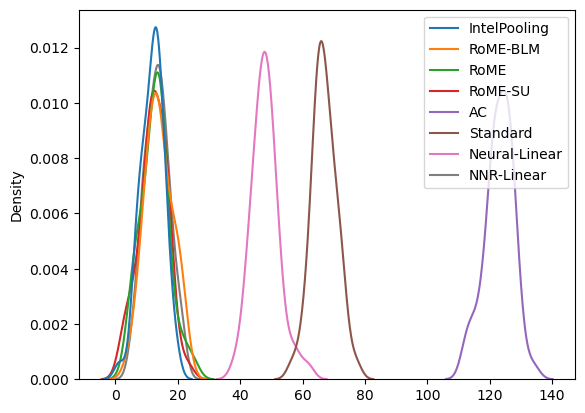

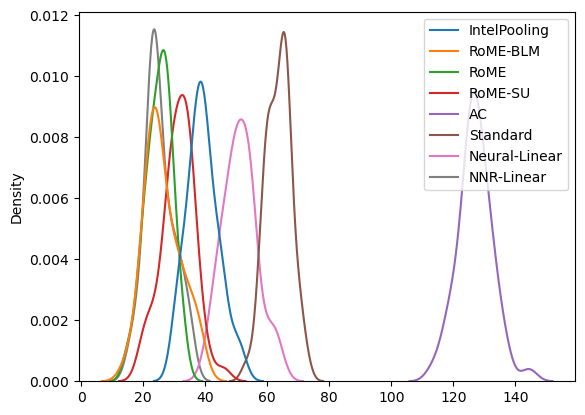

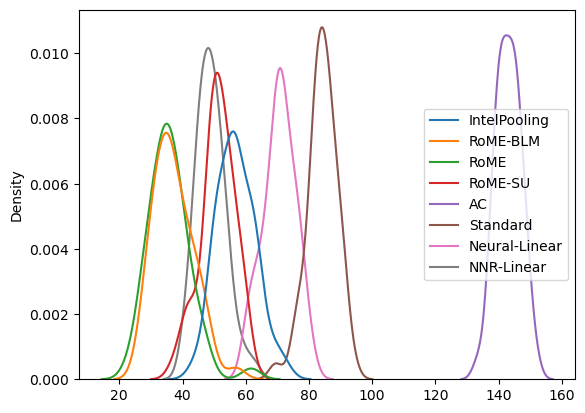

In [40]:
sns.kdeplot(data=final_homogeneous_regret_df)
plt.show()

sns.kdeplot(data=final_heterogeneous_regret_df)
plt.show()

sns.kdeplot(data=final_nonlinear_regret_df)
plt.show()